##### Exploratory Data Analysis for Chicken, Egg and Balloon

This notebook focuses only on the three target classes **Chicken**, **Egg**, and **Balloon** from the Open Images dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import urllib.request

In [ ]:
 # Load the CSV files from the Open Images dataset, filter "Egg, Chicken, Balloon", and save them locally as csv files

# urllib.request.urlretrieve(
#     "https://storage.googleapis.com/openimages/v6/oidv6-train-annotations-bbox.csv",
#     "oidv6-train-annotations-bbox.csv"
# )

# urllib.request.urlretrieve(
#     "https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions-boxable.csv",
#     "oidv7-class-descriptions-boxable.csv"
# )

# boxes = pd.read_csv("oidv6-train-annotations-bbox.csv")
# classes = pd.read_csv(
#     "oidv7-class-descriptions-boxable.csv",
#     header=None,
#     names=["LabelName", "ClassName"]
# )

# df = boxes.merge(classes, on="LabelName", how="left")
# target_classes = ["Chicken", "Egg", "Balloon"]
# interested_classes = df[df["ClassName"].isin(target_classes)].copy()
# interested_classes.to_csv("chicken_egg_balloon_annotations.csv", index=False)


In [ ]:
df = pd.read_csv("chicken_egg_balloon_annotations.csv")
print(df.head())


            ImageID     Source LabelName  Confidence      XMin      XMax  \
0  00028844acae6fae  activemil  /m/01j51           1  0.144375  0.250625   
1  00028844acae6fae     xclick  /m/01j51           1  0.090625  0.322500   
2  00028844acae6fae     xclick  /m/01j51           1  0.748125  0.775000   
3  00028844acae6fae     xclick  /m/01j51           1  0.803125  0.828750   
4  00028844acae6fae     xclick  /m/01j51           1  0.838750  0.881250   

       YMin      YMax  IsOccluded  IsTruncated  ...  IsInside  XClick1X  \
0  0.367827  0.562559          -1           -1  ...        -1 -1.000000   
1  0.352775  0.730950           1            0  ...         0  0.212500   
2  0.439323  0.472248           1            0  ...         0  0.753125   
3  0.529633  0.587959           1            0  ...         0  0.811875   
4  0.615240  0.651928           1            0  ...         0  0.876250   

   XClick2X  XClick3X  XClick4X  XClick1Y  XClick2Y  XClick3Y  XClick4Y  \
0 -1.000000 -1.00

##### EDA 

##### Column Overview

Each row represents one annotated object instance from the filtered subset of **Chicken**, **Egg**, and **Balloon**.

In [5]:
df.columns

Index(['ImageID', 'Source', 'LabelName', 'Confidence', 'XMin', 'XMax', 'YMin',
       'YMax', 'IsOccluded', 'IsTruncated', 'IsGroupOf', 'IsDepiction',
       'IsInside', 'XClick1X', 'XClick2X', 'XClick3X', 'XClick4X', 'XClick1Y',
       'XClick2Y', 'XClick3Y', 'XClick4Y', 'ClassName'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18429 entries, 0 to 18428
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ImageID      18429 non-null  object 
 1   Source       18429 non-null  object 
 2   LabelName    18429 non-null  object 
 3   Confidence   18429 non-null  int64  
 4   XMin         18429 non-null  float64
 5   XMax         18429 non-null  float64
 6   YMin         18429 non-null  float64
 7   YMax         18429 non-null  float64
 8   IsOccluded   18429 non-null  int64  
 9   IsTruncated  18429 non-null  int64  
 10  IsGroupOf    18429 non-null  int64  
 11  IsDepiction  18429 non-null  int64  
 12  IsInside     18429 non-null  int64  
 13  XClick1X     18429 non-null  float64
 14  XClick2X     18429 non-null  float64
 15  XClick3X     18429 non-null  float64
 16  XClick4X     18429 non-null  float64
 17  XClick1Y     18429 non-null  float64
 18  XClick2Y     18429 non-null  float64
 19  XCli

##### Column Descriptions

Each row in the dataset represents one annotated object instance in an image, together with its bounding box coordinates and additional annotation attributes.

- **ImageID**: unique identifier of the image.
- **Source**: source or method used to create the annotation.
- **LabelName**: internal class ID used by Open Images.
- **Confidence**: `1` means the annotation is accepted as correct.
- **XMin**: left x-coordinate of the bounding box.
- **XMax**: right x-coordinate of the bounding box.
- **YMin**: top y-coordinate of the bounding box.
- **YMax**: bottom y-coordinate of the bounding box.
- **IsOccluded**: shows whether the object is partially hidden.
- **IsTruncated**: shows whether the object is cut off by the image border.
- **IsGroupOf**: shows whether the box contains a group of objects.
- **IsDepiction**: shows whether the object is only a depiction, such as a drawing or statue.
- **IsInside**: shows whether the object is inside another object or behind glass.
- **XClick1X**, **XClick2X**, **XClick3X**, **XClick4X**: x-coordinates of annotation click points.
- **XClick1Y**, **XClick2Y**, **XClick3Y**, **XClick4Y**: y-coordinates of annotation click points.
- **ClassName**: readable class name of the object.


In [8]:
# Summarize only the useful numeric columns for the filtered target classes
summary_cols = ["Confidence", "XMin", "XMax", "YMin", "YMax", "IsOccluded", "IsTruncated", "IsGroupOf", "IsDepiction", "IsInside"]
df[summary_cols].describe()

,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,IsGroupOf,IsDepiction,IsInside
count,18429.0,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000
mean,1.0,0.390215,0.595031,0.328564,0.572317,0.651636,0.213739,0.095285,0.030712,-0.015085
std,0.0,0.271377,0.275543,0.245808,0.268927,0.507246,0.445358,0.341307,0.245053,0.122338
min,1.0,0.000000,0.003125,0.000000,0.005008,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.0,0.155625,0.380000,0.121408,0.353659,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.0,0.374882,0.610000,0.299375,0.560337,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.0,0.599375,0.830000,0.496248,0.800581,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.0,0.993750,1.000000,0.988743,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##### Klassenverteilung

Interested classes:
ClassName
Balloon    13505
Chicken     3059
Egg         1865
Name: count, dtype: int64


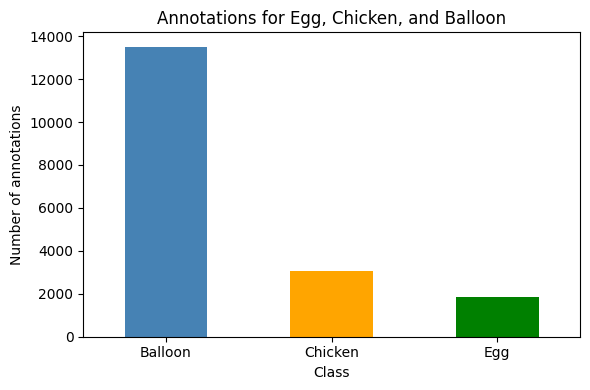

In [ ]:
# Class distribution for the three target classes
print("Interested classes:")
counts = df["ClassName"].value_counts()
print(counts)

plt.figure(figsize=(6,4))
counts.plot(kind="bar", color=["steelblue", "orange", "green"])
plt.title("Annotations for Egg, Chicken, and Balloon")
plt.xlabel("Class")
plt.ylabel("Number of annotations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Die Verteilung ist deutlich unausgewogen: **Balloon** kommt wesentlich häufiger vor als **Chicken** und **Egg**. Diese Imbalance kann später dazu führen, dass das Modell **Balloon** leichter lernt als die selteneren Klassen. Für das Training können deshalb Datenaugmentation, geeignetes Sampling oder Class Weights sinnvoll sein.

##### Anteil der Annotation Flags

   ClassName         Flag    Percent
0    Balloon   IsOccluded  71.475655
1    Chicken   IsOccluded  60.779817
2        Egg   IsOccluded  50.972540
3    Balloon  IsTruncated  24.801498
4    Chicken  IsTruncated  19.724771
5        Egg  IsTruncated  17.448513
6    Balloon    IsGroupOf  10.861423
7    Chicken    IsGroupOf   3.505898
8        Egg    IsGroupOf  27.345538
9    Balloon  IsDepiction   2.666667
10   Chicken  IsDepiction  12.319790
11       Egg  IsDepiction   6.464531
12   Balloon     IsInside   0.007491
13   Chicken     IsInside   0.000000
14       Egg     IsInside   0.000000


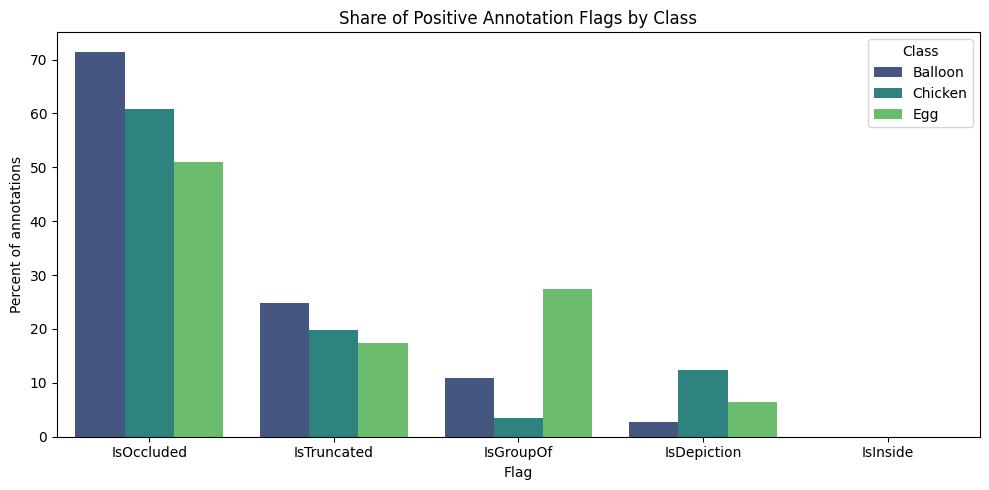

In [ ]:
import seaborn as sns
import numpy as np
flag_columns = ["IsOccluded", "IsTruncated", "IsGroupOf", "IsDepiction", "IsInside"]
flag_data = df[["ClassName"] + flag_columns].replace(-1, np.nan)
flag_percent = (
    flag_data.groupby("ClassName")[flag_columns]
    .mean()
    .mul(100)
    .reset_index()
    .melt(id_vars="ClassName", var_name="Flag", value_name="Percent")
)
print(flag_percent)

plt.figure(figsize=(10, 5))
sns.barplot(data=flag_percent, x="Flag", y="Percent", hue="ClassName", palette="viridis")
plt.title("Share of Positive Annotation Flags by Class")
plt.ylabel("Percent of annotations")
plt.xlabel("Flag")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

Der Plot zeigt, dass sich **Chicken**, **Egg** und **Balloon** deutlich in ihren Annotation Flags unterscheiden. Bei allen drei Klassen ist **IsOccluded** am haeufigsten vertreten, wobei **Balloon** den hoechsten Wert aufweist. Das deutet darauf hin, dass Balloons besonders oft teilweise verdeckt sind und deshalb schwieriger zu erkennen sein koennen.

Auch **IsTruncated** tritt bei **Balloon** am staerksten auf, gefolgt von **Chicken** und **Egg**. **Egg** weist dagegen den hoechsten Anteil bei **IsGroupOf** auf, was darauf hindeutet, dass Eier haeufiger in Gruppen annotiert werden. Bei **IsDepiction** ist **Chicken** am staerksten vertreten, was bedeutet, dass diese Klasse relativ oft auch als Darstellung und nicht nur als reales Objekt vorkommt. **IsInside** spielt fuer alle drei Klassen nahezu keine Rolle.

Insgesamt spricht der Plot dafuer, dass **Balloon** aufgrund der hohen Occlusion- und Truncation-Werte die schwierigste Klasse fuer die Klassifikation sein koennte, waehrend **Egg** vor allem durch Gruppenannotation auffaellt.


##### Bounding-Box-Geometrie

In [ ]:
target_bbox = df[["ClassName", "XMin", "XMax", "YMin", "YMax"]].copy()
target_bbox["Width"] = target_bbox["XMax"] - target_bbox["XMin"]
target_bbox["Height"] = target_bbox["YMax"] - target_bbox["YMin"]
target_bbox["Area"] = target_bbox["Width"] * target_bbox["Height"]
target_bbox["AspectRatio"] = target_bbox["Width"] / target_bbox["Height"]

target_bbox.groupby("ClassName")[["Width", "Height", "Area", "AspectRatio"]].describe().round(3)


Width                                                    Height  \
             count   mean    std    min    25%    50%    75%    max    count   
ClassName                                                                      
Balloon    13505.0  0.160  0.214  0.003  0.041  0.081  0.168  0.999  13505.0   
Chicken     3059.0  0.312  0.243  0.010  0.125  0.236  0.434  1.000   3059.0   
Egg         1865.0  0.355  0.263  0.013  0.158  0.262  0.484  0.999   1865.0   

                  ...   Area        AspectRatio                              \
            mean  ...    75%    max       count   mean    std    min    25%   
ClassName         ...                                                         
Balloon    0.188  ...  0.035  0.999     13505.0  0.864  0.589  0.056  0.567   
Chicken    0.415  ...  0.260  0.999      3059.0  0.798  0.460  0.149  0.526   
Egg        0.366  ...  0.233  0.999      1865.0  1.039  0.560  0.148  0.716   

                                 
             50%    75%     max  
ClassName                        
Balloon    0.706  1.002  15.949  
Chicken    0.706  0.963   8.648  
Egg        0.917  1.168   6.414  

[3 rows x 32 columns]

Die Bounding-Box-Statistiken zeigen deutliche Unterschiede zwischen **Balloon**, **Chicken** und **Egg**. **Balloon** besitzt im Durchschnitt die kleinsten Bounding Boxes, sowohl in der Breite als auch in der Hoehe. Auch die mittlere Flaeche ist bei **Balloon** deutlich geringer als bei den beiden anderen Klassen. Das spricht dafuer, dass Balloons im Datensatz haeufig kleiner dargestellt werden und deshalb fuer das Modell schwieriger zu erkennen sein koennen.

**Chicken** und **Egg** weisen im Mittel deutlich groessere Bounding Boxes auf als **Balloon**. **Egg** hat die groesste durchschnittliche Breite, waehrend **Chicken** die groesste durchschnittliche Hoehe besitzt. Zudem zeigt das Seitenverhaeltnis, dass **Egg** tendenziell breiter beziehungsweise kompakter erscheint, waehrend **Balloon** und **Chicken** im Mittel etwas schmaler sind. Insgesamt deutet die Geometrie darauf hin, dass sich die drei Klassen nicht nur in ihrer Haeufigkeit, sondern auch deutlich in ihrer Objektgroesse und Form unterscheiden, was fuer die spaetere Klassifikation relevant ist.


C:\Users\nuray\AppData\Local\Temp\ipykernel_24188\2529982021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=target_bbox, x="ClassName", y="Width", ax=axes[0], palette="Set2")
C:\Users\nuray\AppData\Local\Temp\ipykernel_24188\2529982021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=target_bbox, x="ClassName", y="Height", ax=axes[1], palette="Set2")
C:\Users\nuray\AppData\Local\Temp\ipykernel_24188\2529982021.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=target_bbox, x="ClassName", y="Area", ax=axes[2], palette

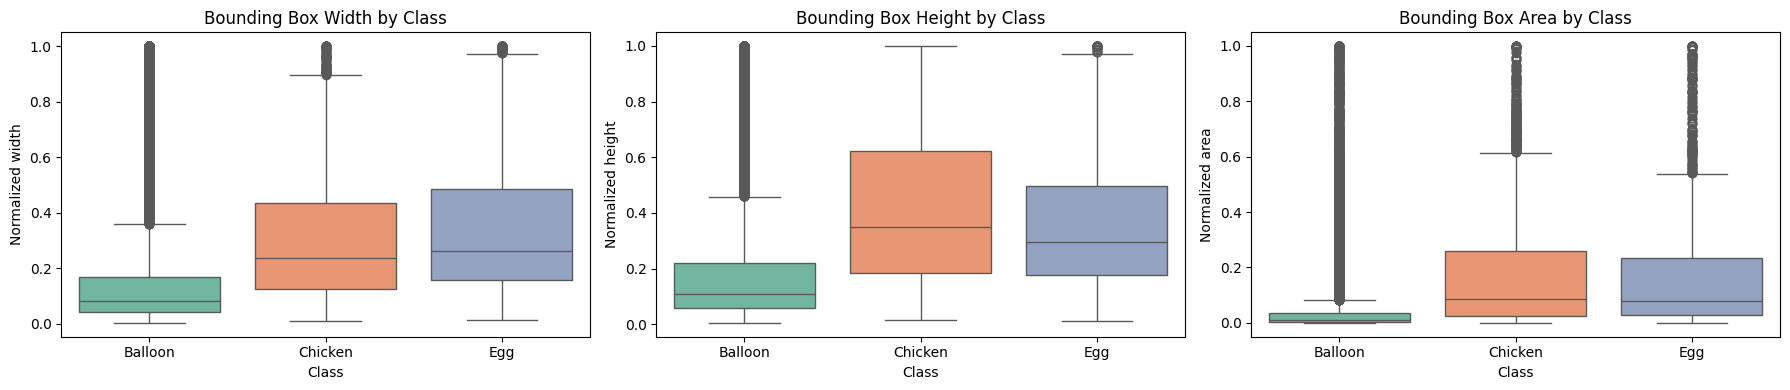

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=target_bbox, x="ClassName", y="Width", ax=axes[0], palette="Set2")
axes[0].set_title("Bounding Box Width by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Normalized width")

sns.boxplot(data=target_bbox, x="ClassName", y="Height", ax=axes[1], palette="Set2")
axes[1].set_title("Bounding Box Height by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Normalized height")

sns.boxplot(data=target_bbox, x="ClassName", y="Area", ax=axes[2], palette="Set2")
axes[2].set_title("Bounding Box Area by Class")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Normalized area")

plt.tight_layout()
plt.show()


count    5610.000000
mean        3.285027
std         7.768436
min         1.000000
50%         1.000000
75%         3.000000
90%         6.000000
95%        10.000000
99%        35.000000
max       206.000000
dtype: float64


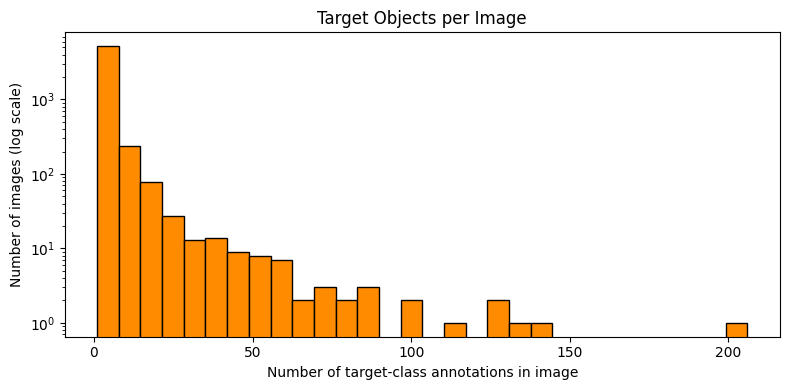

In [ ]:
# Number of target-class annotations per image
target_objects_per_image = df.groupby("ImageID").size()
print(target_objects_per_image.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(target_objects_per_image, bins=30, color="darkorange", edgecolor="black")
plt.yscale("log")
plt.title("Target Objects per Image")
plt.xlabel("Number of target-class annotations in image")
plt.ylabel("Number of images (log scale)")
plt.tight_layout()
plt.show()


- Die meisten Bilder enthalten nur sehr wenige Objekte aus den Zielklassen (starker Peak ganz links).
- Nur sehr wenige Bilder enthalten viele dieser Objekte (rechter Bereich mit abfallenden Werten).

In [ ]:
# Check whether Chicken, Egg and Balloon appear together in the same image
image_class_matrix = (
    df[["ImageID", "ClassName"]]
    .drop_duplicates()
    .assign(value=1)
    .pivot(index="ImageID", columns="ClassName", values="value")
    .fillna(0)
    .astype(int)
)

image_class_matrix["NumTargetClasses"] = image_class_matrix.sum(axis=1)
print(image_class_matrix["NumTargetClasses"].value_counts().sort_index())

cooccurrence = image_class_matrix.drop(columns="NumTargetClasses").T.dot(
    image_class_matrix.drop(columns="NumTargetClasses")
)
cooccurrence


NumTargetClasses
1    5603
2       7
Name: count, dtype: int64


ClassName,Balloon,Chicken,Egg
ClassName,,,
Balloon,3262,0,0
Chicken,0,1421,7
Egg,0,7,934


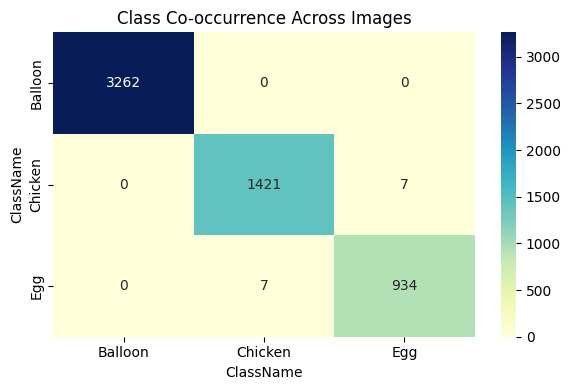

In [36]:
plt.figure(figsize=(6, 4))
sns.heatmap(cooccurrence, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Class Co-occurrence Across Images")
plt.tight_layout()
plt.show()


Die Klassen kommen fast **nicht zusammen** in denselben Bildern vor:
- Balloon: 3262 Bilder (nur Balloon, keine andere Klasse)
- Chicken: 1421 Bilder (nur Chicken)
- Egg: 934 Bilder (nur Egg)
- Nur 7 Bilder enthalten zusammen Chicken UND Egg
- Keine Bilder mit Balloon + Chicken oder Balloon + Egg